# 2.2 — La descente de gradient : comment un modèle apprend

**Navigation** : [<< 2.1-Workflow-ML](2.1-Workflow-ML.ipynb) | [2.3-Regression-lineaire-logistique >>](2.3-Regression-lineaire-logistique.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Dans le notebook **2.1**, nous avons utilisé la méthode `fit()` de scikit-learn comme une boîte noire : on lui donne des données, elle « apprend » un modèle. Mais que se passe-t-il réellement à l'intérieur de cette boîte ? La réponse, pour l'écrasante majorité des modèles de machine learning, tient en un algorithme : la **descente de gradient**. Il s'agit d'une méthode d'optimisation qui ajuste itérativement les paramètres du modèle afin de **réduire progressivement l'erreur** qu'il commet.

Dans ce notebook, nous ouvrons la boîte noire : au lieu d'appeler `fit()`, nous **implémentons nous-mêmes** la descente de gradient sur une régression linéaire. Nous verrons concrètement comment chaque paramètre est mis à jour, et pourquoi le **learning rate** (le pas de descente) est l'hyperparamètre le plus délicat à régler.

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. Définir la fonction de coût **MSE** et expliquer pourquoi on la minimise.
2. Implémenter le **pas de descente de gradient** *from scratch*.
3. Observer l'effet du **learning rate** (convergence lente / bonne / divergence).
4. Vérifier que la descente de gradient retrouve les coefficients de `LinearRegression`.

### Prérequis

- **2.1-Workflow-ML** : métriques d'évaluation, séparation train/test, surapprentissage.
- **Dérivées partielles** : un niveau conceptuel suffit (on manipule le gradient sans calcul formel lourd).

> **Référence.** Cauchy, A.-L. (1847), *Méthode générale pour la résolution des systèmes d'équations simultanées*, Comptes Rendus de l'Académie des Sciences 25:536-538. La méthode de descente dans la direction opposée au gradient y est introduite — c'est l'ancêtre de tout l'apprentissage automatique par optimisation.


In [1]:
# Imports et configuration generale
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print("Configuration OK : 2.2 - Descente de gradient")


Configuration OK : 2.2 - Descente de gradient


## 1. Le problème : la régression linéaire comme un problème de minimisation

Une régression linéaire prédit une cible `y` à partir d'une caractéristique `x` par la relation :

$$\hat{y} = w \cdot x + b$$

où `w` (le poids) et `b` (le biais) sont les **paramètres** que le modèle doit « apprendre ». Apprendre, ici, signifie **trouver les valeurs de `w` et `b` qui rendent l'erreur moyenne aussi petite que possible**. Cette erreur se mesure par la **Mean Squared Error** (MSE, erreur quadratique moyenne) :

$$\mathrm{MSE}(w, b) = \frac{1}{n} \sum_{i=1}^{n} \big( \hat{y}_i - y_i \big)^2 = \frac{1}{n} \sum_{i=1}^{n} \big( w \cdot x_i + b - y_i \big)^2$$

Apprendre le modèle revient donc à **minimiser** la fonction de coût MSE. Pour une régression linéaire, cette fonction est **convexe** (en forme de bol) : elle possède un minimum global unique, que la descente de gradient saura atteindre.

> **Référence.** Gauss (1809), *Theoria Motus Corporum Coelestium* — la méthode des moindres carrés (MCO/MSE) est la fondation historique de la régression linéaire ; voir aussi Hastie, Tibshirani & Friedman (2009), *The Elements of Statistical Learning*, Springer (2e éd.), section 3.2.


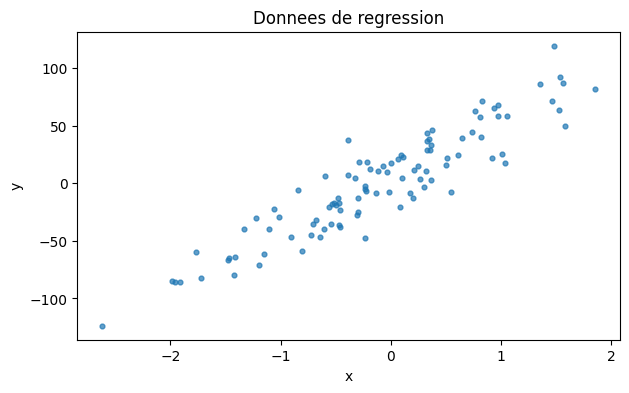

In [2]:
# Generation de donnees de regression 1D (uniquement 1 caracteristique -> cout visualisable)
X, y = make_regression(n_samples=100, n_features=1, noise=20.0, bias=3.0, random_state=42)

plt.figure(figsize=(7, 4))
plt.scatter(X[:, 0], y, s=12, alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Donnees de regression")
plt.show()
# Objectif : trouver les parametres w et b tels que y ~ w*x + b


## 2. La fonction de coût (MSE) et son gradient

Pour minimiser la MSE, la descente de gradient a besoin de savoir **dans quelle direction l'erreur augmente**, afin de partir dans la direction opposée. C'est exactement le rôle du **gradient** : le vecteur des dérivées partielles de la fonction de coût par rapport à chaque paramètre. Pour la MSE on obtient, après dérivation :

$$\frac{\partial \mathrm{MSE}}{\partial w} = -\frac{2}{n} \sum_{i=1}^{n} x_i \big(y_i - (w \cdot x_i + b)\big) \qquad \frac{\partial \mathrm{MSE}}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} \big(y_i - (w \cdot x_i + b)\big)$$

La règle de mise à jour de la descente de gradient est alors :

$$w \leftarrow w - \mathrm{lr} \cdot \frac{\partial \mathrm{MSE}}{\partial w} \qquad b \leftarrow b - \mathrm{lr} \cdot \frac{\partial \mathrm{MSE}}{\partial b}$$

On descend dans la **direction opposée au gradient**, d'un pas contrôlé par le **learning rate** `lr`. Répétée un grand nombre de fois, cette mise à jour fait glisser `(w, b)` vers le fond du bol = le minimum de l'erreur.

> **Référence.** Nocedal, J. & Wright, S.J. (2006), *Numerical Optimization*, Springer (2e éd.), chapitres 2-3. La convergence, le choix du pas (learning rate) et la condition de Lipschitz de la fonction de coût y sont analysés.


In [3]:
def mse(y_true, y_pred):
    """Cout MSE = moyenne des carres des erreurs."""
    return np.mean((y_pred - y_true) ** 2)


def mse_gradients(X, y, w, b):
    """Derivees partielles de la MSE par rapport a w et b.

    dMSE/dw = (-2/n) * somme[ x_i * (y_i - (w*x_i + b)) ]
    dMSE/db = (-2/n) * somme[ (y_i - (w*x_i + b)) ]
    """
    n = len(y)
    y_pred = w * X[:, 0] + b
    error = y - y_pred  # residus (y_i - y_pred_i)
    dw = (-2.0 / n) * np.sum(X[:, 0] * error)
    db = (-2.0 / n) * np.sum(error)
    return dw, db


# Verification rapide au point de depart (w=0, b=0)
dw0, db0 = mse_gradients(X, y, w=0.0, b=0.0)
cout0 = mse(y, 0.0 * X[:, 0] + 0.0)
print(f"Au depart (w=0, b=0) : MSE={cout0:.4f}, dw={dw0:.4f}, db={db0:.4f}")
print("Le gradient indique la direction dans laquelle le cout augmente ; on ira a l'oppose.")


Au depart (w=0, b=0) : MSE=2126.3453, dw=-76.8802, db=-0.8712
Le gradient indique la direction dans laquelle le cout augmente ; on ira a l'oppose.


### Exercice 1 : calculer le coût MSE

Avant d'automatiser la descente, vérifions que vous savez calculer la fonction de coût vous-même. Implémentez la MSE « à la main » et évaluez-la au point de départ `(w=0, b=0)`.

**Objectif** : écrire `mse_etudiant(y_true, y_pred)` qui renvoie la moyenne des carrés des erreurs, puis l'appliquer pour obtenir un nombre.

- `# Indice` : la MSE est la moyenne (`np.mean`) du carré de l'écart `(y_pred - y_true)`.
- `# Etape 1` : remplir le corps de `mse_etudiant`.
- `# Etape 2` : calculer `y_pred_test` pour `w_test=0, b_test=0`, puis `cout_test`.


In [4]:
# Exercice 1 : calculer le MSE entre y_true et y_pred
# TODO etudiant : implementer la moyenne des carres des erreurs
def mse_etudiant(y_true, y_pred):
    cout = None  # TODO etudiant : remplacer
    return cout

# Test rapide sur un poids initial quelconque
w_test, b_test = 0.0, 0.0
y_pred_test = w_test * X[:, 0] + b_test
cout_test = None  # TODO etudiant : utiliser mse_etudiant
print(f"Exercice 1 a completer : MSE initial (w=0, b=0) = {cout_test}")


Exercice 1 a completer : MSE initial (w=0, b=0) = None


## 3. La boucle de descente de gradient

Nous avons la fonction de coût et son gradient. Il ne reste qu'à **boucler** : à chaque itération, on calcule le gradient à la position courante, puis on met à jour les paramètres en faisant un petit pas dans la direction opposée. Répétée suffisamment de fois, cette boucle **est** l'apprentissage.

Le **learning rate** `lr` fixe la taille de ce pas :

- **Trop petit** : la descente est **lente**, il faut beaucoup d'itérations pour atteindre le minimum.
- **Bon** : la descente converge **rapidement et sûrement** vers le fond du bol.
- **Trop grand** : les pas sont exagérés, la MSE **oscille, puis diverge** (le coût explose).


In [5]:
def gradient_descent(X, y, w_init, b_init, lr, n_iters):
    """Boucle de descente de gradient sur la MSE.

    Met a jour :  w <- w - lr * dMSE/dw
                  b <- b - lr * dMSE/db
    Renvoie l'historique des parametres et des pertes.
    """
    w, b = w_init, b_init
    history_w = [w]
    history_b = [b]
    losses = [mse(y, w * X[:, 0] + b)]
    for _ in range(n_iters):
        # 1. Gradient a la position courante
        dw, db = mse_gradients(X, y, w, b)
        # 2. Pas de descente : direction OPPOSEE au gradient
        w = w - lr * dw
        b = b - lr * db
        # 3. Enregistrer l'etat
        history_w.append(w)
        history_b.append(b)
        losses.append(mse(y, w * X[:, 0] + b))
    return history_w, history_b, losses


# Execution avec un learning rate raisonnable
hist_w, hist_b, losses = gradient_descent(
    X, y, w_init=0.0, b_init=0.0, lr=0.05, n_iters=100
)
print(f"GD final : w={hist_w[-1]:.4f}, b={hist_b[-1]:.4f}, MSE final={losses[-1]:.4f}")


GD final : w=47.1209, b=5.3247, MSE final=312.2171


## 4. Visualiser la descente : la courbe de coût

Le moyen le plus immédiat de **voir** l'apprentissage est de tracer la MSE en fonction du numéro d'itération. Si tout se passe bien, cette courbe **décroît de manière monotone** vers un plateau : c'est la convergence rendue visible. Sur le même graphique, on superpose la droite ajustée aux données pour constater que le modèle a bien « appris » la relation linéaire.


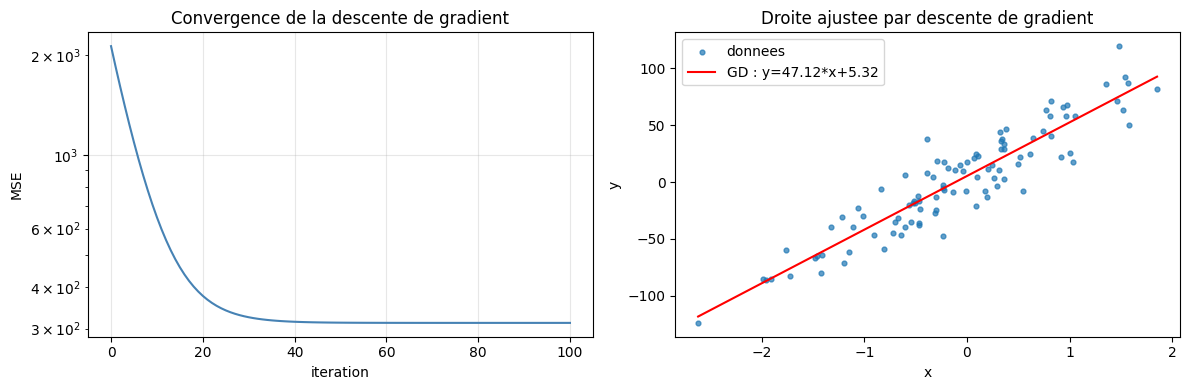

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Courbe de cout (echelle log pour bien voir la decroissance)
axes[0].plot(range(len(losses)), losses, color="steelblue")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("MSE")
axes[0].set_title("Convergence de la descente de gradient")
axes[0].set_yscale("log")
axes[0].grid(alpha=0.3)

# Droite ajustee sur les donnees
w_final, b_final = hist_w[-1], hist_b[-1]
axes[1].scatter(X[:, 0], y, s=12, alpha=0.7, label="donnees")
x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
axes[1].plot(
    x_line,
    w_final * x_line + b_final,
    color="red",
    label=f"GD : y={w_final:.2f}*x+{b_final:.2f}",
)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Droite ajustee par descente de gradient")
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. L'effet du learning rate

Le learning rate est **le** paramètre le plus sensible de la descente de gradient. Visualisons les trois régimes côte à côte sur les mêmes données : un pas minuscule (convergence paresseuse), un bon pas (convergence franche), et un pas trop grand (divergence). La différence est frappante et illustre pourquoi régler ce paramètre est crucial en pratique.


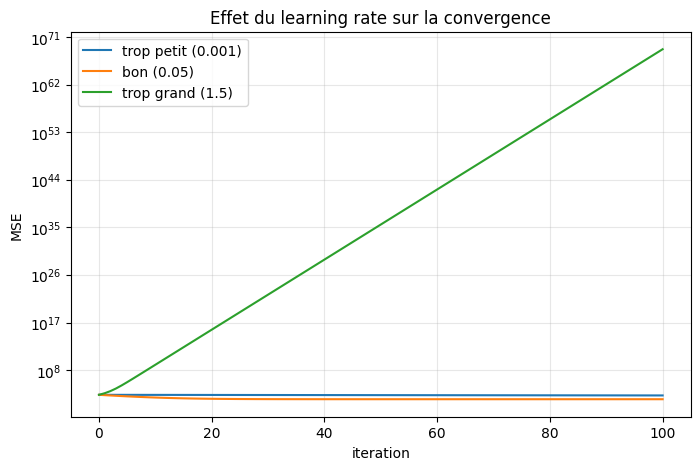

In [7]:
# Comparaison de trois regimes de learning rate.
# Sur ces donnees (x ~ N(0,1)), le gradient en w a une pente ~2*x^2 ~= 2 :
# la divergence commence pour lr > ~1.0. On choisit donc 1.5 pour provoquer l'explosion.
learning_rates = {
    "trop petit (0.001)": 0.001,
    "bon (0.05)": 0.05,
    "trop grand (1.5)": 1.5,
}

plt.figure(figsize=(8, 5))
for label, lr in learning_rates.items():
    with np.errstate(over="ignore", invalid="ignore"):
        _, _, losses_lr = gradient_descent(
            X, y, w_init=0.0, b_init=0.0, lr=lr, n_iters=100
        )
    plt.plot(range(len(losses_lr)), losses_lr, label=label)

plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title("Effet du learning rate sur la convergence")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# Le courbe "trop grand" explose (puis devient inf/nan -> non tracee apres divergence).


### Exercice 2 : trouver le learning rate qui fait diverger la descente

Dans cette exercice, vous allez **déclencher volontairement la divergence**. Choisissez un learning rate supérieur au seuil de divergence observé ci-dessus, lancez la descente de gradient, puis détectez automatiquement que la perte a explosé.

**Objectif** : renvoyer `diverge = True` si la dernière perte est `NaN` ou nettement supérieure à la perte initiale.

- `# Indice` : essayez plusieurs valeurs de `lr` au-dessus du seuil (ex. 1.5, 2.0, 5.0) et observez.
- `# Indice` : `np.isnan(valeur)` permet de tester si un nombre est `NaN`.
- `# Etape 1` : fixer `lr_trop_grand` à une valeur divergente.
- `# Etape 2` : récupérer la liste `pertes_divergentes` via `gradient_descent`.
- `# Etape 3` : calculer le booléen `diverge`.


In [8]:
# Exercice 2 : trouver un learning rate trop grand (divergence)
lr_trop_grand = None  # TODO etudiant : choisir une valeur > seuil de divergence
# TODO etudiant : lancer gradient_descent avec ce lr et recuperer les pertes
pertes_divergentes = None  # TODO etudiant : remplacer (liste des pertes)
diverge = None  # TODO etudiant : True si la derniere perte est NaN ou >> perte initiale
print(f"Exercice 2 a completer : lr={lr_trop_grand}, diverge={diverge}")


Exercice 2 a completer : lr=None, diverge=None


## 6. La descente de gradient retrouve-t-elle les coefficients sklearn ?

Comment savoir si notre implémentation « maison » est correcte ? La validation la plus simple consiste à comparer notre résultat à celui de scikit-learn. `LinearRegression` ne fait pas de descente de gradient : elle **résout exactement** le problème des moindres carrés à l'aide des équations normales (solution analytique). Puisque les deux approches minimisent **la même fonction de coût convexe**, elles doivent converger vers **la même solution**. C'est notre test de cohérence.


In [9]:
# Reference : sklearn resout les moindres carres analytiquement (equations normales)
model = LinearRegression()
model.fit(X, y)
w_sklearn = model.coef_[0]
b_sklearn = model.intercept_

w_gd, b_gd = hist_w[-1], hist_b[-1]

print(f"sklearn : w = {w_sklearn:.4f}, b = {b_sklearn:.4f}")
print(f"GD      : w = {w_gd:.4f}, b = {b_gd:.4f}")
print(f"Ecart absolu : |dw| = {abs(w_sklearn - w_gd):.4f}, |db| = {abs(b_sklearn - b_gd):.4f}")
# GD converge vers la meme solution car les deux minimisent la MSE sur un cout convexe.


sklearn : w = 47.1332, b = 5.3302
GD      : w = 47.1209, b = 5.3247
Ecart absolu : |dw| = 0.0124, |db| = 0.0055


## 7. Pourquoi standardiser avant la descente de gradient

Lorsque les caractéristiques ont des échelles très différentes (par exemple l'une en mètres et l'autre en millimètres), la fonction de coût n'est plus un bol « rond » mais un bol **allongé**. La descente de gradient fait alors des pas **anisotropes** : lents dans la direction de la grande échelle, instables dans l'autre, ce qui ralentit fortement la convergence.

La **standardisation** (vue avec `StandardScaler` dans le pipeline du notebook 2.1) ramène toutes les caractéristiques à une variance comparable : le bol redevient rond, et la descente converge beaucoup plus vite. C'est l'une des raisons pour lesquelles la standardisation est quasi systématique avant l'entraînement.


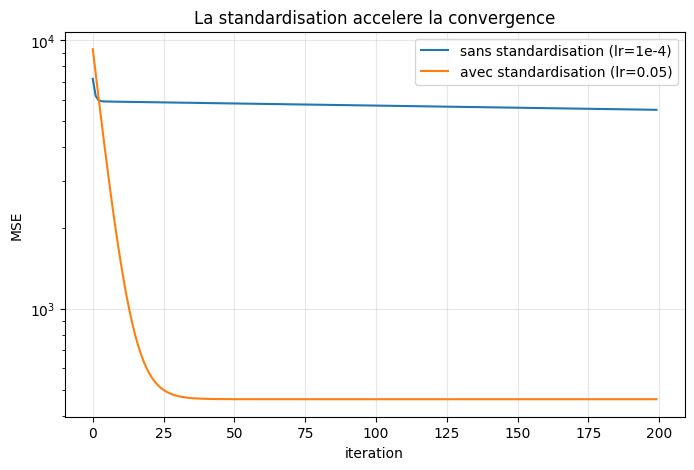

In [10]:
# Donnees 2D avec des echelles tres differentes
X2, y2 = make_regression(n_samples=100, n_features=2, noise=20.0, bias=3.0, random_state=42)
X2[:, 0] = X2[:, 0] * 100.0  # la 1re caracteristique a une grande echelle


def mse_grad_2d(X, y, w, b):
    """Gradient de la MSE pour un vecteur de poids w (2D)."""
    n = len(y)
    y_pred = X @ w + b
    error = y - y_pred
    dw = (-2.0 / n) * (X.T @ error)
    db = (-2.0 / n) * np.sum(error)
    return dw, db


def gd_2d(X, y, lr, n_iters):
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = []
    for _ in range(n_iters):
        dw, db = mse_grad_2d(X, y, w, b)
        w = w - lr * dw
        b = b - lr * db
        y_pred = X @ w + b
        losses.append(np.mean((y - y_pred) ** 2))
    return losses


# Sans standardisation : lr tres petit pour rester stable sur la grande echelle
losses_raw = gd_2d(X2, y2, lr=0.0001, n_iters=200)

# Avec standardisation : le bol est "rond", on peut utiliser un lr beaucoup plus grand
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
losses_scaled = gd_2d(X2_scaled, y2, lr=0.05, n_iters=200)

plt.figure(figsize=(8, 5))
plt.plot(range(len(losses_raw)), losses_raw, label="sans standardisation (lr=1e-4)")
plt.plot(range(len(losses_scaled)), losses_scaled, label="avec standardisation (lr=0.05)")
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title("La standardisation accelere la convergence")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Exercice 3 : accélérer la convergence par la standardisation

Quantifions le gain apporté par la standardisation. Comptez combien d'itérations il faut à la descente de gradient pour descendre sous un seuil de perte fixé, **sans** puis **avec** standardisation, et rapportez le rapport entre les deux.

- `# Etape 1` : parcourir `losses_raw` (sans scaling) et trouver la première itération où la perte passe sous `seuil`.
- `# Etape 2` : faire de même avec `losses_scaled` (avec `StandardScaler`).
- `# Etape 3` : si l'une des deux n'atteint jamais le seuil, notez `None` et commentez.


In [11]:
# Exercice 3 : nombre d'iterations pour atteindre une perte cible, sans vs avec standardisation
seuil = 50.0  # seuil de perte a atteindre
# TODO etudiant : compter les iterations (sans scaling) ou la perte descend sous le seuil
n_iter_sans = None  # TODO etudiant : remplacer
# TODO etudiant : idem avec StandardScaler sur X
n_iter_avec = None  # TODO etudiant : remplacer
print(f"Exercice 3 a completer : iters sans/avec standardisation = {n_iter_sans} / {n_iter_avec}")


Exercice 3 a completer : iters sans/avec standardisation = None / None


## Conclusion et transition

Nous avons ouvert la boîte noire `fit()` :

- La **fonction de coût MSE** mesure l'erreur du modèle ; l'apprentissage consiste à la minimiser.
- Le **gradient** indique la direction de la hausse d'erreur ; la descente de gradient fait un pas dans la direction **opposée**.
- Le **learning rate** contrôle la taille du pas : trop petit = lent, trop grand = divergence.
- La **standardisation** arrondit le bol et accélère fortement la convergence.
- Notre implémentation *from scratch* **retrouve les coefficients de `LinearRegression`**, ce qui valide son exactitude.

Ces idées (fonction de coût, gradient, learning rate) sont universelles : ce sont les mêmes qui pilotent les réseaux de neurones profonds via la rétropropagation.

**Transition.** Le prochain notebook, [`2.3-Regression-lineaire-logistique`](2.3-Regression-lineaire-logistique.ipynb), passe de la **régression continue** (prédire un nombre) à la **classification binaire** (prédire une étiquette 0/1), en réutilisant exactement cette intuition d'optimisation par descente de gradient.


## References

1. Cauchy, A.-L. (1847). *Méthode générale pour la résolution des systèmes d'équations simultanées*. Comptes Rendus de l'Académie des Sciences 25:536-538. — L'ancêtre de la descente de gradient.
2. Nocedal, J. & Wright, S.J. (2006). *Numerical Optimization*. Springer (2e éd.). — Convergence, choix du pas (learning rate), analyse des méthodes de descente.
3. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer (2e éd.), section 3.2. — Régression linéaire par moindres carrés et fonction de coût MSE.
4. Rumelhart, D.E., Hinton, G.E. & Williams, R.J. (1986). *Learning representations by back-propagating errors*. Nature 323:533-536. — La descente de gradient appliquée aux réseaux de neurones (rétropropagation).
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `LinearRegression` et `StandardScaler` utilisés pour la validation.
